# 🌿 Deforestation Analysis — EuroSAT Land Use Classifier
**Model:** EfficientNetB0 (Transfer Learning) | **Dataset:** EuroSAT Sentinel-2 | **Classes:** 10

In [12]:
# ── Cell 1: Imports & GPU Check ─────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# GPU Check
print('TensorFlow Version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f'✅ GPU Available: {gpus[0].name}')
else:
    print('⚠️  No GPU found — Running on CPU')

# Config
BASE_DIR   = os.getcwd()
IMG_SIZE   = (64, 64)
BATCH_SIZE = 32
EPOCHS_P1  = 15   # Phase 1 — frozen base
EPOCHS_P2  = 50   # Phase 2 — fine-tuning
NUM_CLASSES = 10

CLASS_NAMES = [
    'AnnualCrop', 'Forest', 'HerbaceousVegetation',
    'Highway', 'Industrial', 'Pasture',
    'PermanentCrop', 'Residential', 'River', 'SeaLake'
]
print('\nConfig ready ✅')

TensorFlow Version: 2.21.0
⚠️  No GPU found — Running on CPU

Config ready ✅


In [3]:
# ── Cell 2: Load CSV Files ───────────────────────────────────
train_df = pd.read_csv(os.path.join(BASE_DIR, 'train.csv'))
val_df   = pd.read_csv(os.path.join(BASE_DIR, 'validation.csv'))
test_df  = pd.read_csv(os.path.join(BASE_DIR, 'test.csv'))

# Build full file paths
train_df['filepath'] = train_df['Filename'].apply(lambda x: os.path.join(BASE_DIR, x))
val_df['filepath']   = val_df['Filename'].apply(lambda x: os.path.join(BASE_DIR, x))
test_df['filepath']  = test_df['Filename'].apply(lambda x: os.path.join(BASE_DIR, x))

print(f'Train samples      : {len(train_df)}')
print(f'Validation samples : {len(val_df)}')
print(f'Test samples       : {len(test_df)}')
print(f'\nClass distribution in training set:')
print(train_df['ClassName'].value_counts())

Train samples      : 18900
Validation samples : 5400
Test samples       : 2700

Class distribution in training set:
ClassName
AnnualCrop              2100
HerbaceousVegetation    2100
Residential             2100
SeaLake                 2100
Forest                  2100
PermanentCrop           1750
Industrial              1750
Highway                 1750
River                   1750
Pasture                 1400
Name: count, dtype: int64


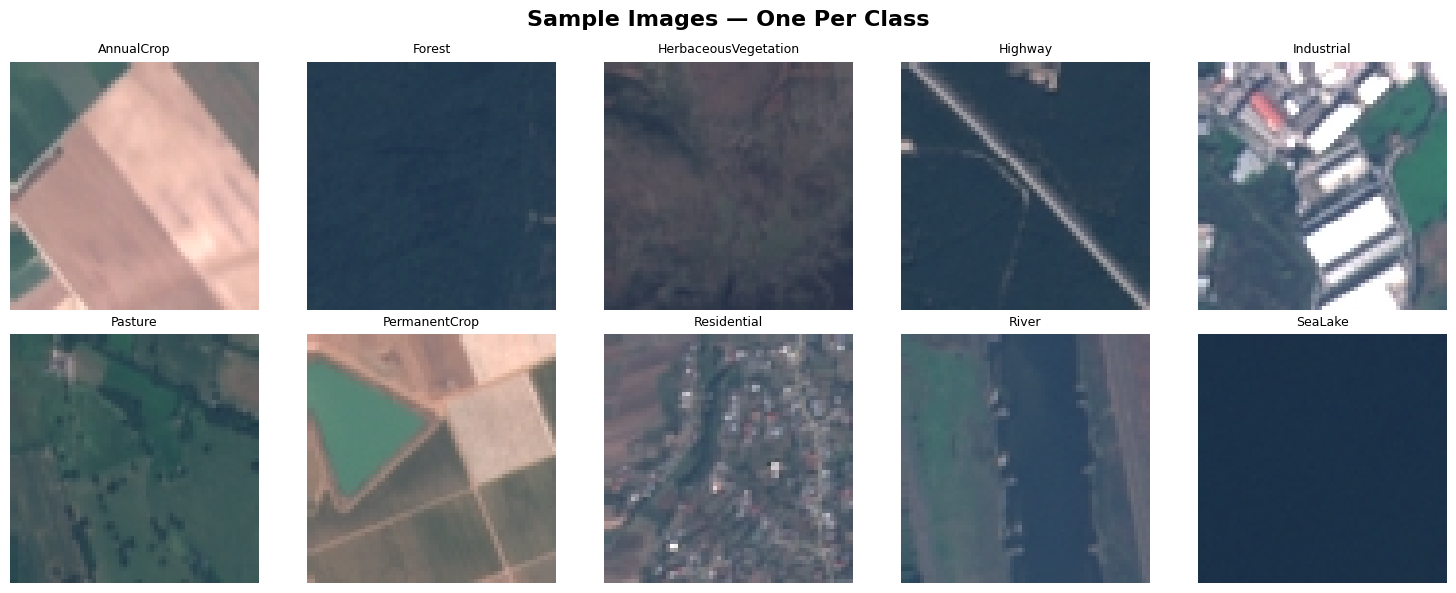

Sample images saved as sample_images.png ✅


In [4]:
# ── Cell 3: Visualize Sample Images ─────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images — One Per Class', fontsize=16, fontweight='bold')

for idx, class_name in enumerate(CLASS_NAMES):
    sample = train_df[train_df['ClassName'] == class_name].iloc[0]
    img = plt.imread(sample['filepath'])
    ax = axes[idx // 5][idx % 5]
    ax.imshow(img)
    ax.set_title(class_name, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print('Sample images saved as sample_images.png ✅')

In [5]:
# ── Cell 4: Build tf.data Pipeline ──────────────────────────
def load_image(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)   # Keep [0,255] — EfficientNet rescales internally
    return img, label

# Augmentation for training only
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
], name='augmentation')

def apply_augmentation(img, label):
    img = data_augmentation(img, training=True)
    return img, label

AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(df, augment=False, shuffle=False):
    paths  = df['filepath'].values
    labels = df['Label'].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=42)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(apply_augmentation, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, augment=True, shuffle=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

print(f'Train batches      : {len(train_ds)}')
print(f'Validation batches : {len(val_ds)}')
print(f'Test batches       : {len(test_ds)}')
print('\nData pipeline ready ✅')

Train batches      : 591
Validation batches : 169
Test batches       : 85

Data pipeline ready ✅


In [6]:
# ── Cell 5: Build EfficientNetB0 Model ──────────────────────
def build_model(num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=(64, 64, 3), name='input')

    # EfficientNetB0 base — pretrained on ImageNet, frozen
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )
    base_model.trainable = False   # Freeze for Phase 1

    # Custom classification head
    x = base_model.output
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn')(x)
    x = layers.Dense(256, activation='relu', name='dense1')(x)
    x = layers.Dropout(0.3, name='dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs, outputs, name='EfficientNetB0_EuroSAT')
    return model, base_model

model, base_model = build_model()
model.summary()


print(f'\n📊 Trainable params (Phase 1): {model.count_params():,}')
print(f'   Base frozen: {not base_model.trainable}')

Model: "EfficientNetB0_EuroSAT"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 64, 64, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 64, 64, 3) │          0 │ input[0][0]       │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 64, 64, 3) │          7 │ rescaling[0][0]   │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 64, 64, 3) │          0 │ normalization[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 65, 65, 3) │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 32, 32,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 32, 32,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 32, 32,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 32, 32,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 32, 32,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 32, 32,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 32, 32,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 32, 32,    │        512 │ block1a_se_excit… │
│ (Conv2D)            │ 16)               │            │                 

 Total params: 4,385,197 (16.73 MB)

 Trainable params: 333,066 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)


📊 Trainable params (Phase 1): 4,385,197
   Base frozen: True


In [7]:
# ── Cell 6: Compile Model ────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    keras.callbacks.TensorBoard(log_dir='logs/phase1')
]

print('Model compiled ✅')
print('Callbacks ready: ModelCheckpoint | EarlyStopping | ReduceLROnPlateau | TensorBoard')

Model compiled ✅
Callbacks ready: ModelCheckpoint | EarlyStopping | ReduceLROnPlateau | TensorBoard


In [9]:
# ── Cell 7: Train Phase 1 (Frozen Base) ─────────────────────
print('🚀 Starting Phase 1 Training — Head only (base frozen)...')
print(f'   Epochs: {EPOCHS_P1} | Batch Size: {BATCH_SIZE}\n')

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P1,
    callbacks=callbacks,
    verbose=1
)

print(f'\n✅ Phase 1 Complete!')
print(f'   Best Val Accuracy: {max(history1.history["val_accuracy"]):.4f}')

🚀 Starting Phase 1 Training — Head only (base frozen)...
   Epochs: 15 | Batch Size: 32

Epoch 1/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7624 - loss: 0.7521
Epoch 1: val_accuracy improved from None to 0.87648, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 50s 84ms/step - accuracy: 0.8137 - loss: 0.5888 - val_accuracy: 0.8765 - val_loss: 0.3665 - learning_rate: 0.0010
Epoch 2/15
590/591 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8570 - loss: 0.4287
Epoch 2: val_accuracy did not improve from 0.87648
591/591 ━━━━━━━━━━━━━━━━━━━━ 50s 85ms/step - accuracy: 0.8607 - loss: 0.4186 - val_accuracy: 0.8707 - val_loss: 0.4074 - learning_rate: 0.0010
Epoch 3/15
590/591 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.8764 - loss: 0.3665
Epoch 3: val_accuracy improved from 0.87648 to 0.88241, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 78s 7

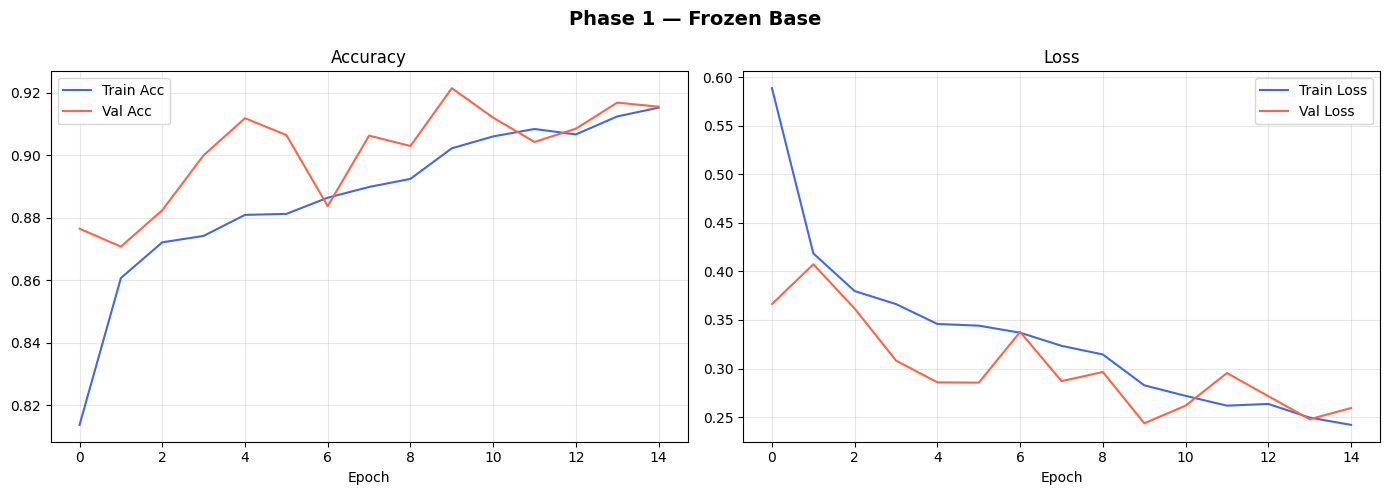

In [10]:
# ── Cell 8: Plot Phase 1 Curves ─────────────────────────────
def plot_history(history, title='Training'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Acc', color='royalblue')
    axes[0].plot(history.history['val_accuracy'], label='Val Acc',   color='tomato')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss', color='royalblue')
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='tomato')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}.png', dpi=100)
    plt.show()

plot_history(history1, 'Phase 1 — Frozen Base')

🔧 Starting Phase 2 — Fine-tuning top layers...
   Unfrozen layers: 20 / 238
Epoch 1/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8085 - loss: 0.5733
Epoch 1: val_accuracy improved from None to 0.86537, saving model to best_model_finetuned.keras

Epoch 1: finished saving model to best_model_finetuned.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 66s 96ms/step - accuracy: 0.8171 - loss: 0.5532 - val_accuracy: 0.8654 - val_loss: 0.4317
Epoch 2/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8271 - loss: 0.5118
Epoch 2: val_accuracy improved from 0.86537 to 0.87759, saving model to best_model_finetuned.keras

Epoch 2: finished saving model to best_model_finetuned.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 54s 90ms/step - accuracy: 0.8296 - loss: 0.5066 - val_accuracy: 0.8776 - val_loss: 0.3968
Epoch 3/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8378 - loss: 0.4831
Epoch 3: val_accuracy improved from 0.87759 to 0.88685, saving model to best_model_finetuned.keras

Epoch 

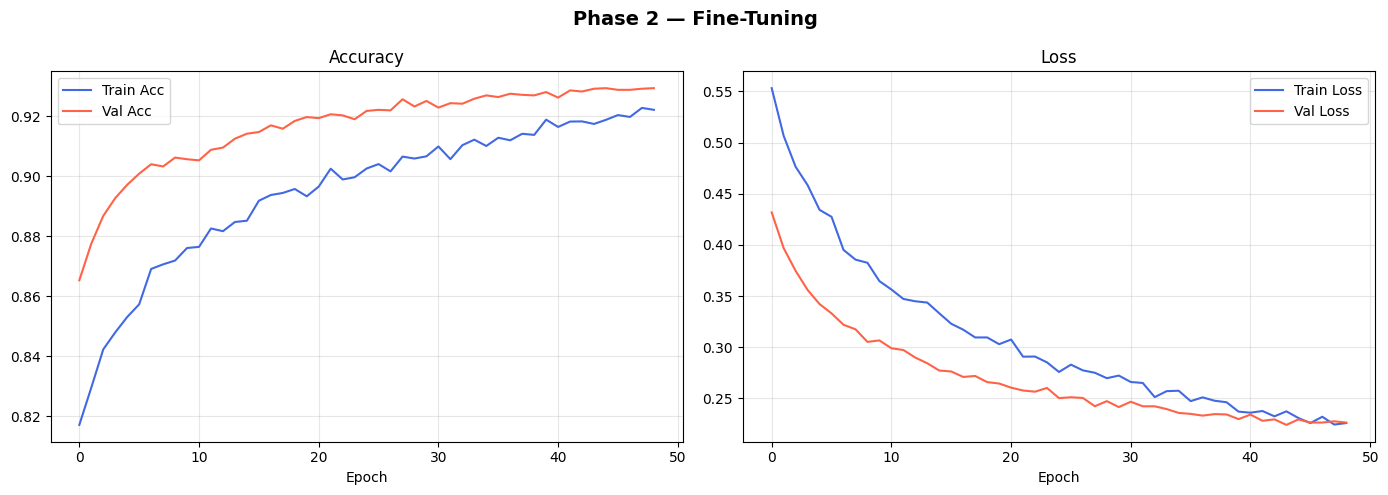

In [13]:
# ── Cell 9: Fine-Tuning Phase 2 ─────────────────────────────
print('🔧 Starting Phase 2 — Fine-tuning top layers...')

# Unfreeze the last 20 layers of EfficientNetB0
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'   Unfrozen layers: {trainable_count} / {len(base_model.layers)}')

# Recompile with lower LR for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_p2 = [
    keras.callbacks.ModelCheckpoint(
        'best_model_finetuned.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.TensorBoard(log_dir='logs/phase2')
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P2,
    callbacks=callbacks_p2,
    verbose=1
)

print(f'\n✅ Phase 2 Complete!')
print(f'   Best Val Accuracy: {max(history2.history["val_accuracy"]):.4f}')

plot_history(history2, 'Phase 2 — Fine-Tuning')

In [18]:
# ── Cell 9B: Phase 3 — 50 layer Fine-Tuning ─────────────────────
print('🔥 Starting Phase 3 - 50 layer Model Fine-Tuning...')

# Poora EfficientNetB0 unfreeze
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'   {50} layers unfrozen: {trainable_count}')

# Phase 3 mein aur bhi chhota learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # 10x chhota Phase 2 se
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_p3 = [
    keras.callbacks.ModelCheckpoint(
        'best_model_phase3.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]

history3 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks_p3,
    verbose=1
)

print(f'\n✅ Phase 3 Complete!')
print(f'   Best Val Accuracy: {max(history3.history["val_accuracy"]):.4f}')

plot_history(history3, 'Phase 3 — Full Fine-Tuning')


🔥 Starting Phase 3 - 50 layer Model Fine-Tuning...
   50 layers unfrozen: 20
Epoch 1/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9149 - loss: 0.2362
Epoch 1: val_accuracy improved from None to 0.92870, saving model to best_model_phase3.keras

Epoch 1: finished saving model to best_model_phase3.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 68s 99ms/step - accuracy: 0.9188 - loss: 0.2300 - val_accuracy: 0.9287 - val_loss: 0.2270 - learning_rate: 1.0000e-05
Epoch 2/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9196 - loss: 0.2281
Epoch 2: val_accuracy improved from 0.92870 to 0.92889, saving model to best_model_phase3.keras

Epoch 2: finished saving model to best_model_phase3.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 57s 96ms/step - accuracy: 0.9207 - loss: 0.2267 - val_accuracy: 0.9289 - val_loss: 0.2269 - learning_rate: 1.0000e-05
Epoch 3/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9225 - loss: 0.2236
Epoch 3: val_accuracy improved from 0.92889 to 0.93000, sa

KeyboardInterrupt: 

In [14]:
# ── Cell 10: Evaluate on Test Set ───────────────────────────
print('📊 Evaluating on Test Set...')
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f'\n🎯 Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'   Test Loss     : {test_loss:.4f}')

# Get predictions
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print('\n📋 Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

📊 Evaluating on Test Set...
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.9363 - loss: 0.1971

🎯 Test Accuracy : 0.9363 (93.63%)
   Test Loss     : 0.1971

📋 Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.93      0.96      0.95       300
              Forest       0.88      0.99      0.93       300
HerbaceousVegetation       0.94      0.91      0.92       300
             Highway       0.89      0.91      0.90       250
          Industrial       0.95      0.96      0.95       250
             Pasture       0.97      0.91      0.94       200
       PermanentCrop       0.90      0.88      0.89       250
         Residential       0.98      0.99      0.99       300
               River       0.93      0.93      0.93       250
             SeaLake       0.99      0.90      0.95       300

            accuracy                           0.94      2700
           macro avg       0.94      0.93      0.94      2700
   

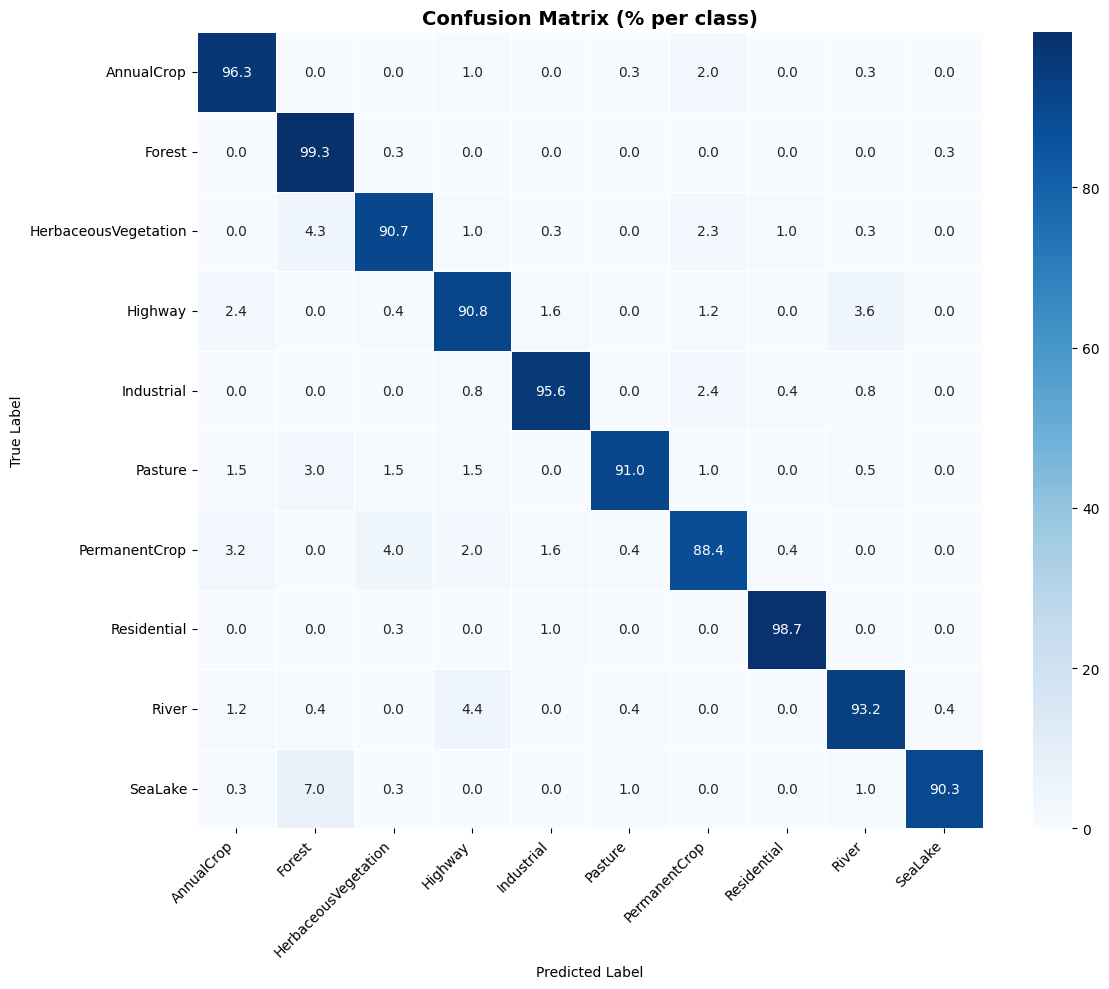

Confusion matrix saved ✅


In [15]:
# ── Cell 11: Confusion Matrix ────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_pct,
    annot=True, fmt='.1f',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5
)
plt.title('Confusion Matrix (% per class)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()
print('Confusion matrix saved ✅')

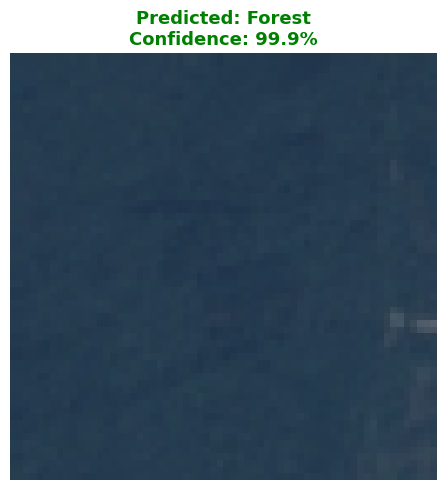


🏷️  Predicted Class : Forest
   Confidence      : 99.88%

📊 All class probabilities:
   AnnualCrop                  0.0% 
   Forest                     99.9% █████████████████████████████
   HerbaceousVegetation        0.1% 
   Highway                     0.0% 
   Industrial                  0.0% 
   Pasture                     0.0% 
   PermanentCrop               0.0% 
   Residential                 0.0% 
   River                       0.0% 
   SeaLake                     0.0% 


In [16]:
# ── Cell 12: Predict on a Single Image ──────────────────────
def predict_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = tf.expand_dims(img, axis=0)  # Add batch dim

    predictions = model.predict(img, verbose=0)[0]
    pred_idx    = np.argmax(predictions)
    confidence  = predictions[pred_idx] * 100

    # Display
    plt.figure(figsize=(6, 5))
    plt.imshow(plt.imread(image_path))
    plt.title(
        f'Predicted: {CLASS_NAMES[pred_idx]}\nConfidence: {confidence:.1f}%',
        fontsize=13, fontweight='bold', color='green'
    )
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f'\n🏷️  Predicted Class : {CLASS_NAMES[pred_idx]}')
    print(f'   Confidence      : {confidence:.2f}%')
    print('\n📊 All class probabilities:')
    for name, prob in zip(CLASS_NAMES, predictions):
        bar = '█' * int(prob * 30)
        print(f'   {name:<25} {prob*100:5.1f}% {bar}')

# Test on a sample image from the dataset
sample_path = train_df[train_df['ClassName'] == 'Forest'].iloc[0]['filepath']
predict_image(sample_path)

In [17]:
# ── Cell 13: Save Final Model ────────────────────────────────
model.save('deforestation_model.keras')
print('✅ Model saved as: deforestation_model.keras')
print()

# Load test
loaded_model = keras.models.load_model('deforestation_model.keras')
print('✅ Model loaded back successfully!')
print()
print('=' * 50)
print('🎉 Training Complete!')
print('=' * 50)
print(f'   Test Accuracy     : {test_acc*100:.2f}%')
print(f'   Model File        : deforestation_model.keras')
print(f'   Best Model (P1)   : best_model.keras')
print(f'   Best Model (P2)   : best_model_finetuned.keras')
print(f'   Plots             : sample_images.png | confusion_matrix.png')
print('=' * 50)

✅ Model saved as: deforestation_model.keras

✅ Model loaded back successfully!

🎉 Training Complete!
   Test Accuracy     : 93.63%
   Model File        : deforestation_model.keras
   Best Model (P1)   : best_model.keras
   Best Model (P2)   : best_model_finetuned.keras
   Plots             : sample_images.png | confusion_matrix.png
